# 📈 Instagram Reach Analysis and Prediction

![Instagram Analysis Banner](https://github.com/RKYEngineering/instagram-reach-analysis-and-prediction/blob/main/instagram-reach-analysis-banner.png)

This project analyzes Instagram post performance using Data Analytics and Machine Learning techniques. The goal is to identify the factors affecting Instagram reach and build a predictive model for estimating post impressions based on engagement metrics, posting behavior, and content features.

The project includes:
- Data Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Machine Learning Prediction
- Performance Evaluation

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

#L**oad Dataset**

In [65]:
df = pd.read_csv("https://raw.githubusercontent.com/RKYEngineering/instagram-reach-analysis-and-prediction/refs/heads/main/data/instagram_reach_realistic.csv")
df.head(5)

,Date,Posting_Hour,Post_Type,Followers,Likes,Comments,Shares,Saves,Profile Visits,Follows,From Home,From Hashtags,From Explore,From Other,Impressions,Caption,Hashtags
0,2024-06-13,19,Carousel,126958,4093,96,182,295,2591,137,22558,9325,7981,1606,41470,Expert win medical civil relationship camera c...,#always #ground #step #camera #while #expert #...
1,2025-03-23,21,Reel,189779,8432,180,261,488,2377,466,41359,11847,28543,22547,104296,Character guess spend third perhaps firm diffi...,#consider #office #hot #hot #professor #head #...
2,2025-06-27,18,Reel,336236,14382,1100,467,819,3694,312,70191,35692,47945,22442,176270,Officer official stand both under perform when...,#road #student #end #long #local #feeling #pho...
3,2024-08-03,13,Carousel,111530,5483,169,220,327,1403,189,15391,9778,10366,7669,43204,Enjoy gas strong want either recent old activity.,#perhaps #film #create #but #west #never #eye ...
4,2025-07-11,15,Image,955110,28905,2245,1265,2379,10625,1466,110153,38754,41623,12312,202842,Picture church school cut worry service yes le...,#talk #standard #south #quite #site #fund #thr...


#**Dataset Information**

In [66]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Shape of Dataset:
(5000, 17)

Column Names:
Index(['Date', 'Posting_Hour', 'Post_Type', 'Followers', 'Likes', 'Comments',
       'Shares', 'Saves', 'Profile Visits', 'Follows', 'From Home',
       'From Hashtags', 'From Explore', 'From Other', 'Impressions', 'Caption',
       'Hashtags'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            5000 non-null   object
 1   Posting_Hour    5000 non-null   int64 
 2   Post_Type       5000 non-null   object
 3   Followers       5000 non-null   int64 
 4   Likes           5000 non-null   int64 
 5   Comments        5000 non-null   int64 
 6   Shares          5000 non-null   int64 
 7   Saves           5000 non-null   int64 
 8   Profile Visits  5000 non-null   int64 
 9   Follows         5000 non-null   int64 
 10  From Home       5000 non-null   i

#**Statistical Summary**

In [67]:
df.describe()

,Posting_Hour,Followers,Likes,Comments,Shares,Saves,Profile Visits,Follows,From Home,From Hashtags,From Explore,From Other,Impressions
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,11.465200,497047.717800,22090.393400,1103.305400,660.370200,1439.400800,7843.946800,975.270800,70961.881000,27663.750600,39459.485000,19997.838600,157500.312200
std,6.870854,285382.230524,17245.173686,980.323327,603.128074,1251.433433,6554.875103,916.840794,51916.612014,21629.088932,30531.202716,22002.005172,113085.691923
min,0.000000,5064.000000,104.000000,2.000000,1.000000,7.000000,32.000000,2.000000,408.000000,147.000000,235.000000,0.000000,1000.000000
25%,6.000000,250892.000000,9019.750000,402.000000,227.000000,540.000000,2994.250000,324.000000,30439.000000,11448.500000,16065.000000,3801.250000,68172.500000
50%,11.000000,493280.500000,18015.500000,834.000000,489.000000,1122.000000,6066.000000,682.500000,60420.000000,22471.000000,32665.000000,12994.500000,135350.500000
75%,17.000000,742197.750000,30566.250000,1492.000000,907.000000,1951.000000,10984.500000,1330.000000,100109.750000,38460.250000,54564.750000,29053.250000,223185.000000
max,23.000000,999923.000000,109875.000000,7431.000000,5269.000000,9054.000000,40249.000000,6926.000000,285800.000000,133232.000000,186892.000000,185748.000000,596356.000000




- The dataset contains 5,000 Instagram posts with realistic engagement and reach metrics.
- Average impressions are approximately 157,500 per post.
- Average likes are around 22,090, indicating strong audience engagement.
- Home feed contributes the highest share of impressions, followed by Explore and Hashtags.
- Posting hours vary throughout the day, allowing analysis of optimal posting times.


#**Check Missing Values**

In [68]:
df.isnull().sum()

,0
Date,0
Posting_Hour,0
Post_Type,0
Followers,0
Likes,0
Comments,0
Shares,0
Saves,0
Profile Visits,0
Follows,0


- No missing values were found in any column of the dataset.
- Complete data improves the reliability of analysis and machine learning predictions.
- No additional data imputation or cleaning is required before further processing.

#**Data Cleaning and Preprocessing**

In [69]:
# Remove duplicate rows
# df.drop_duplicates(inplace=True)
# No duplicate rows found

# Fill missing values
#df.fillna(0, inplace=True)
# No missing values found

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Extract date features
df["Day"] = df["Date"].dt.day

df["Month"] = df["Date"].dt.month

df["Year"] = df["Date"].dt.year

df["Weekday"] = df["Date"].dt.weekday

# Display dataset
df.head()

,Date,Posting_Hour,Post_Type,Followers,Likes,Comments,Shares,Saves,Profile Visits,Follows,From Home,From Hashtags,From Explore,From Other,Impressions,Caption,Hashtags,Day,Month,Year,Weekday
0,2024-06-13,19,Carousel,126958,4093,96,182,295,2591,137,22558,9325,7981,1606,41470,Expert win medical civil relationship camera c...,#always #ground #step #camera #while #expert #...,13,6,2024,3
1,2025-03-23,21,Reel,189779,8432,180,261,488,2377,466,41359,11847,28543,22547,104296,Character guess spend third perhaps firm diffi...,#consider #office #hot #hot #professor #head #...,23,3,2025,6
2,2025-06-27,18,Reel,336236,14382,1100,467,819,3694,312,70191,35692,47945,22442,176270,Officer official stand both under perform when...,#road #student #end #long #local #feeling #pho...,27,6,2025,4
3,2024-08-03,13,Carousel,111530,5483,169,220,327,1403,189,15391,9778,10366,7669,43204,Enjoy gas strong want either recent old activity.,#perhaps #film #create #but #west #never #eye ...,3,8,2024,5
4,2025-07-11,15,Image,955110,28905,2245,1265,2379,10625,1466,110153,38754,41623,12312,202842,Picture church school cut worry service yes le...,#talk #standard #south #quite #site #fund #thr...,11,7,2025,4



- The Date column was converted to datetime format for time-based analysis.
- New features (Day, Month, Year, and Weekday) were extracted from the Date column.
- These features help analyze posting patterns and improve machine learning performance.

#**Feature Engineering**

In [70]:
# Caption Length
df["Caption_Length"] = (
    df["Caption"]
    .astype(str)
    .apply(len)
)

# Hashtag Count
df["Hashtag_Count"] = (
    df["Hashtags"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# Engagement Rate
df["Engagement_Rate"] = (
    (
        df["Likes"] +
        df["Comments"] +
        df["Shares"] +
        df["Saves"]
    ) / df["Followers"]
) * 100

# Display dataset
df.head()

,Date,Posting_Hour,Post_Type,Followers,Likes,Comments,Shares,Saves,Profile Visits,Follows,From Home,From Hashtags,From Explore,From Other,Impressions,Caption,Hashtags,Day,Month,Year,Weekday,Caption_Length,Hashtag_Count,Engagement_Rate
0,2024-06-13,19,Carousel,126958,4093,96,182,295,2591,137,22558,9325,7981,1606,41470,Expert win medical civil relationship camera c...,#always #ground #step #camera #while #expert #...,13,6,2024,3,68,14,3.675231
1,2025-03-23,21,Reel,189779,8432,180,261,488,2377,466,41359,11847,28543,22547,104296,Character guess spend third perhaps firm diffi...,#consider #office #hot #hot #professor #head #...,23,3,2025,6,79,14,4.932579
2,2025-06-27,18,Reel,336236,14382,1100,467,819,3694,312,70191,35692,47945,22442,176270,Officer official stand both under perform when...,#road #student #end #long #local #feeling #pho...,27,6,2025,4,140,10,4.986973
3,2024-08-03,13,Carousel,111530,5483,169,220,327,1403,189,15391,9778,10366,7669,43204,Enjoy gas strong want either recent old activity.,#perhaps #film #create #but #west #never #eye ...,3,8,2024,5,49,12,5.558146
4,2025-07-11,15,Image,955110,28905,2245,1265,2379,10625,1466,110153,38754,41623,12312,202842,Picture church school cut worry service yes le...,#talk #standard #south #quite #site #fund #thr...,11,7,2025,4,127,15,3.642931



- Three new features were created: Caption_Length, Hashtag_Count, and Engagement_Rate.
- Engagement rates range around 3%–6%, indicating realistic audience interaction.
- Caption lengths and hashtag usage vary across posts, providing additional information for analysis.
- These engineered features can improve model performance and help identify factors affecting Instagram reach.

#**Encode Categorical Features**

In [71]:
# Create Label Encoder
le = LabelEncoder()

# Encode Post_Type column
df["Post_Type"] = le.fit_transform(
    df["Post_Type"]
)

# Display dataset
df.head()

,Date,Posting_Hour,Post_Type,Followers,Likes,Comments,Shares,Saves,Profile Visits,Follows,From Home,From Hashtags,From Explore,From Other,Impressions,Caption,Hashtags,Day,Month,Year,Weekday,Caption_Length,Hashtag_Count,Engagement_Rate
0,2024-06-13,19,0,126958,4093,96,182,295,2591,137,22558,9325,7981,1606,41470,Expert win medical civil relationship camera c...,#always #ground #step #camera #while #expert #...,13,6,2024,3,68,14,3.675231
1,2025-03-23,21,2,189779,8432,180,261,488,2377,466,41359,11847,28543,22547,104296,Character guess spend third perhaps firm diffi...,#consider #office #hot #hot #professor #head #...,23,3,2025,6,79,14,4.932579
2,2025-06-27,18,2,336236,14382,1100,467,819,3694,312,70191,35692,47945,22442,176270,Officer official stand both under perform when...,#road #student #end #long #local #feeling #pho...,27,6,2025,4,140,10,4.986973
3,2024-08-03,13,0,111530,5483,169,220,327,1403,189,15391,9778,10366,7669,43204,Enjoy gas strong want either recent old activity.,#perhaps #film #create #but #west #never #eye ...,3,8,2024,5,49,12,5.558146
4,2025-07-11,15,1,955110,28905,2245,1265,2379,10625,1466,110153,38754,41623,12312,202842,Picture church school cut worry service yes le...,#talk #standard #south #quite #site #fund #thr...,11,7,2025,4,127,15,3.642931


- The `Post_Type` column was converted into numerical values using Label Encoding.
- This transformation allows machine learning models to process categorical data.
- Three post categories (Carousel, Image, and Reel) were successfully encoded.
- The dataset is now fully prepared for correlation analysis and model training.

#**Exploratory Data Analysis (EDA)**

#**Correlation Heatmap**

This heatmap visualizes relationships between numerical features.

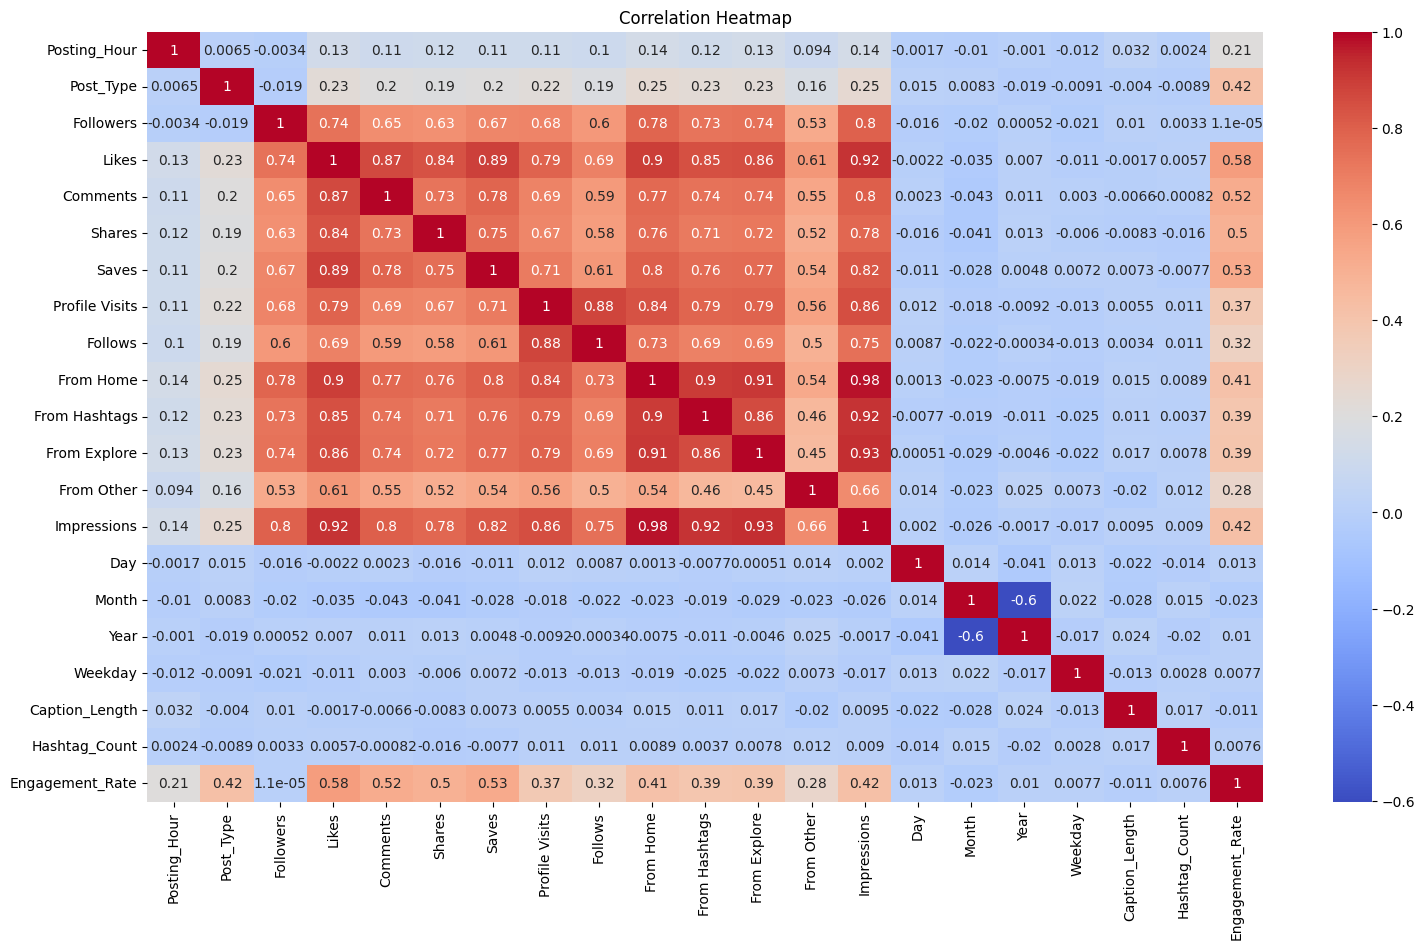

In [72]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## **Analysis**

- Posts with higher likes, saves, and profile visits tend to generate significantly more impressions, showing that audience engagement is closely linked to content reach.
- Home Feed, Explore, and Hashtag discovery channels contribute the majority of impressions, making them key sources of Instagram visibility.
- Engagement rate is primarily driven by likes, comments, and saves, indicating that meaningful user interactions are strong indicators of content performance.
- Posting time has a moderate impact on engagement, suggesting that timing can improve results but is less influential than content quality.
- Caption length and hashtag count have minimal influence on reach, implying that relevance and audience interest matter more than quantity.

#**Likes vs Impressions Analysis**

This scatter plot visualizes the relationship between likes and impressions.

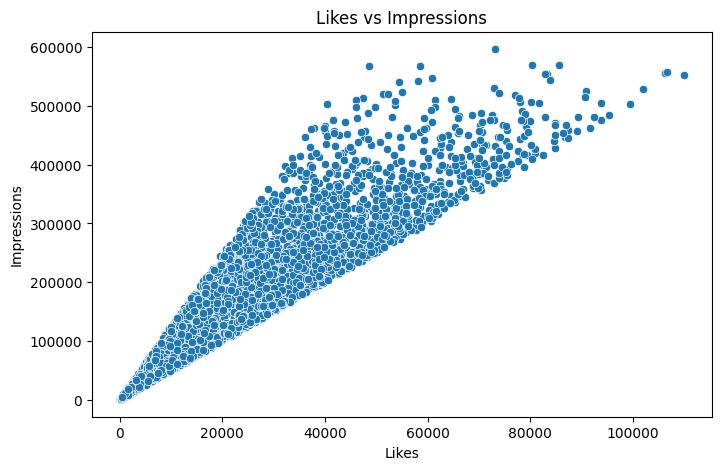

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Likes"],
    y=df["Impressions"]
)

plt.title("Likes vs Impressions")

plt.xlabel("Likes")

plt.ylabel("Impressions")

plt.show()

## **Analysis**

- A strong positive relationship exists between likes and impressions, indicating that posts receiving more engagement generally achieve higher reach.
- As likes increase, impressions also increase, suggesting that highly engaging content is more likely to be promoted and discovered by a larger audience.
- The spread of points at higher like counts shows that reach is influenced by additional factors such as post type, posting time, audience behavior, and Instagram discovery channels.
- While likes are a strong indicator of performance, they are not the sole driver of impressions, highlighting the importance of a comprehensive content strategy.

#**Post Type vs Average Impressions**

This visualization compares the average impressions across different post types.

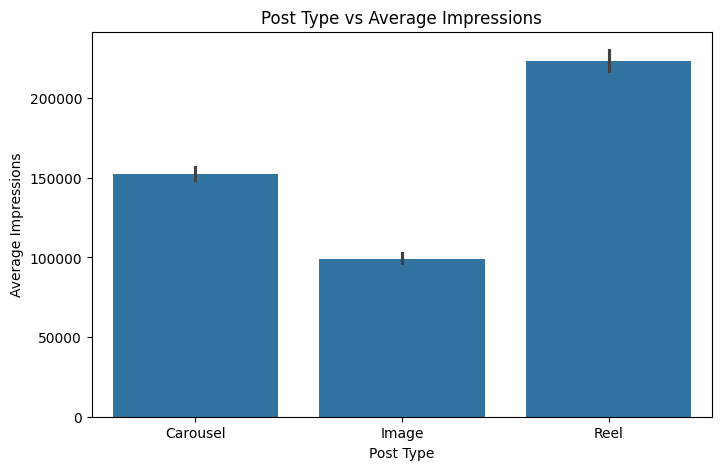

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Post_Type"],
    y=df["Impressions"]
)

plt.title("Post Type vs Average Impressions")

plt.xlabel("Post Type")

plt.ylabel("Average Impressions")

plt.xticks(
    [0, 1, 2],
    ["Carousel", "Image", "Reel"]
)

plt.show()

## **Analysis**
- Reels achieve the highest average impressions, making them the most effective content format for reach.

- Carousel posts deliver moderate performance, while Image posts generate the lowest average impressions.

- This suggests that prioritizing Reels can help maximize audience visibility and content reach.

# **Posting Hour vs Average Impressions**

This visualization analyzes how posting time affects impressions.

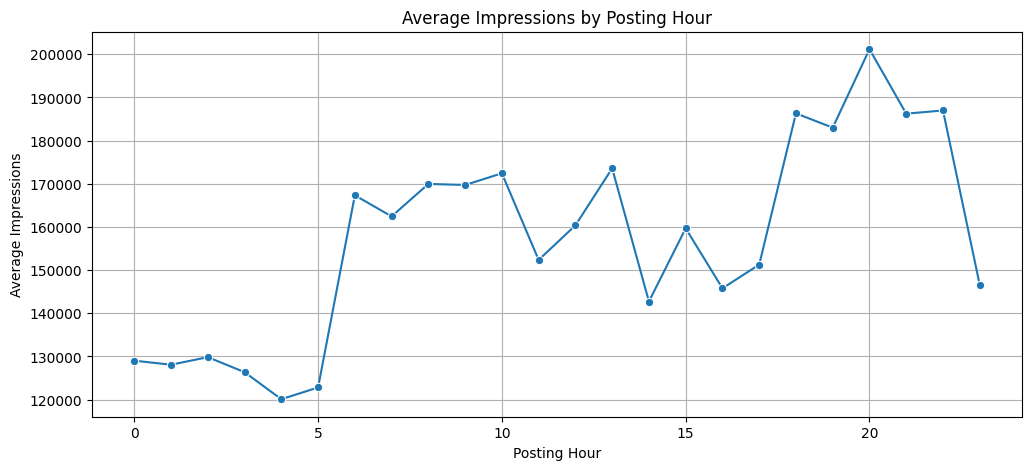

In [75]:
hourly_avg = (
    df.groupby("Posting_Hour")["Impressions"]
    .mean()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker="o"
)

plt.title("Average Impressions by Posting Hour")

plt.xlabel("Posting Hour")

plt.ylabel("Average Impressions")

plt.grid(True)

plt.show()

## **Analysis**
- Audience activity is lowest during early morning hours and gradually increases throughout the day.

- The highest average impressions are observed during evening hours, particularly between 6 PM and 10 PM.

- This suggests that publishing content during peak evening periods can improve visibility and maximize reach.

# **Feature Selection**

In [76]:
X = df.drop(
    columns=[
        "Date",
        "Caption",
        "Hashtags",
        "Impressions",
        "From Home",
        "From Explore",
        "From Hashtags",
        "From Other"
    ]
)

y = df["Impressions"]

print("Feature Variables Shape:", X.shape)

print("Target Variable Shape:", y.shape)

Feature Variables Shape: (5000, 16)
Target Variable Shape: (5000,)


- The final dataset contains 5,000 Instagram posts and 16 predictor variables used for model training.

- These features capture post characteristics, audience size, engagement metrics, traffic sources, posting time, and content-related attributes.

- The target variable is Impressions, which represents the reach achieved by each post and serves as the prediction objective.

# **Train-Test Split**

The dataset is divided into training and testing sets.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

X_train Shape: (4000, 16)
X_test Shape: (1000, 16)
y_train Shape: (4000,)
y_test Shape: (1000,)


# **Model Building**

A Random Forest Regressor model is used for predicting Instagram impressions.

In [78]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


- A Random Forest Regressor was trained using 100 decision trees to learn patterns between post attributes and Instagram impressions.

- The model combines predictions from multiple trees, helping improve accuracy and reduce the risk of overfitting.

- This trained model is used to estimate the expected reach of future Instagram posts.

# **Model Prediction**

The trained model predicts impressions on test data.

In [79]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")

print(y_pred[:10])

First 10 Predictions:
[ 91525.47  65155.76  38178.68 393098.12 163355.39 362438.91 115966.92
  32680.57 238025.45  33900.49]


- The model successfully generated impression predictions for unseen Instagram posts.

- Predicted reach values vary significantly across posts, ranging from around 32,000 to over 393,000 impressions, indicating that post characteristics strongly influence performance.

- These predictions can help content creators estimate potential reach and make data-driven publishing decisions.

# **Model Evaluation**

In [80]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Absolute Error: 15380.04973
Root Mean Squared Error: 22343.279279954957
R2 Score: 0.962254009911333


## **Model Performance Insight**

- The Random Forest model achieved a strong prediction performance with an R² score of 0.96, meaning it explains approximately 96% of the variation in Instagram impressions.

- On average, predictions differ from actual impressions by about 15,380 impressions (MAE), indicating a relatively low prediction error considering the scale of the dataset.

- These results suggest that the selected features effectively capture the factors influencing Instagram reach and enable accurate impression forecasting.

# **Actual vs Predicted Impressions**

This visualization compares actual impressions with predicted impressions.

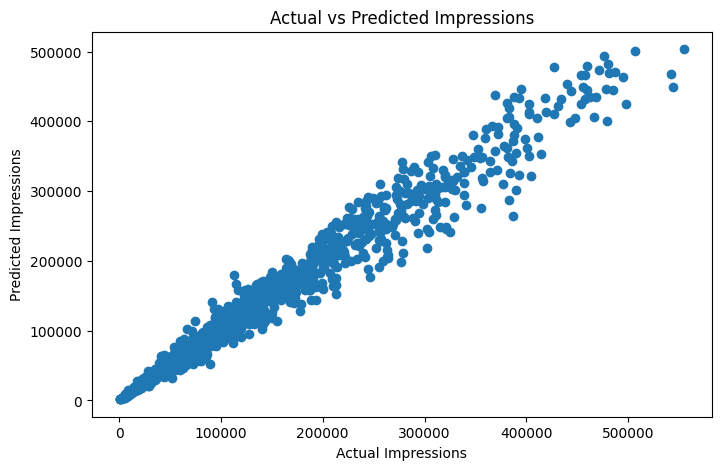

In [81]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Impressions")

plt.ylabel("Predicted Impressions")

plt.title("Actual vs Predicted Impressions")

plt.show()

- The predicted impressions closely align with the actual impressions, indicating that the model is able to capture underlying patterns in Instagram post performance.

- Most data points follow a clear upward trend, demonstrating strong predictive accuracy and reliable forecasting capability.

- This suggests that the model can be used to estimate post reach and support data-driven content planning decisions.

# **Feature Importance Analysis**

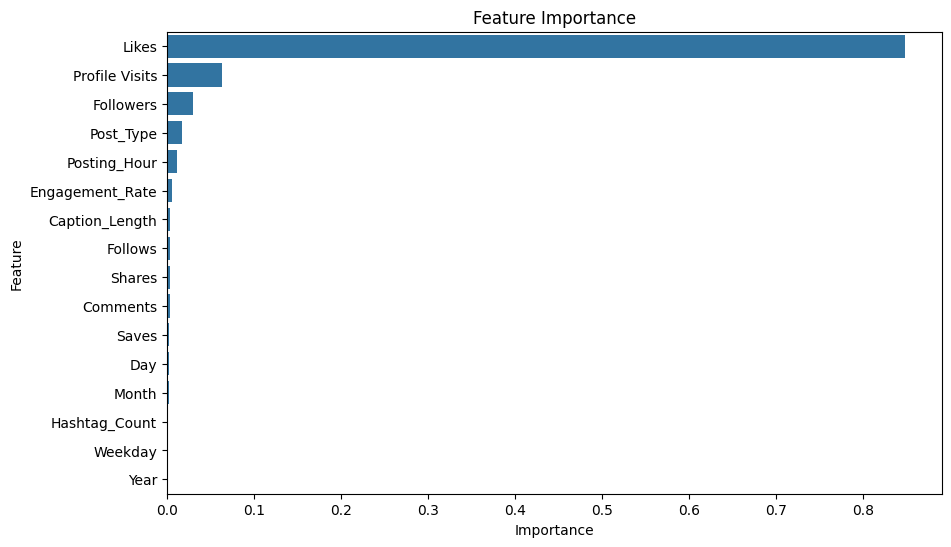

In [82]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance["Importance"],
    y=importance["Feature"]
)

plt.title("Feature Importance")

plt.show()

- Likes are by far the most influential factor in predicting Instagram impressions, indicating a strong relationship between audience engagement and post reach.

- Profile Visits and Followers also contribute to prediction performance, but their impact is significantly lower than Likes.

- Content-related features such as Caption Length, Hashtag Count, and Posting Day have minimal influence, suggesting that audience interaction is a stronger driver of reach than content formatting choices.

## **📌 Conclusion**

In this project, Instagram engagement and reach data were analyzed to identify the factors that influence post impressions.

Exploratory Data Analysis revealed that Reels generally achieve higher reach than other post formats, while engagement metrics such as Likes, Profile Visits, and Followers play a significant role in driving impressions.

A Random Forest Regressor was trained to predict post impressions and achieved an **R² Score of 0.96**, demonstrating strong predictive performance.

Overall, the results show that audience engagement has a much greater impact on reach than content formatting factors such as caption length or hashtag count. These insights can help creators and marketers make more informed, data-driven content decisions.
